# Datathon 2026 — Stage 3: Prophet Trend + Residual Models (Revenue + COGS)

**Input**: `features_ready.csv` + `feature_meta.json` (từ Stage 2)

**Strategy**:
- `Prophet` học **trend + seasonality** cho từng target (`Revenue`, `COGS`)
- `LightGBM` và `CatBoost` học **residual = target - Prophet trend** cho cả Revenue và COGS
- Backtest cố định: `2021-01-01 -> 2022-12-31`
- Forecast tương lai: Prophet tạo base trend, residual models hiệu chỉnh bằng recursive lag features

**Output**:
- Revenue models: `lgbm_rev.pkl`, `catboost_rev.cbm`, `prophet_rev.pkl`
- COGS models: `lgbm_cogs.pkl`, `catboost_cogs.cbm`, `prophet_cogs.pkl`
- Predictions: `oof_predictions.csv`, `cv_scores.json`, `test_predictions.csv`

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import json
import pickle
from datetime import datetime

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from prophet import Prophet

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

OUTPUT_DIR = r'd:\datathon_2026\train_model\Datathon_2026'
RANDOM_STATE = 42

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def score_report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    r    = rmse(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:25s}  MAE={mae:>14,.0f}  RMSE={r:>14,.0f}  R²={r2:.4f}')
    return {'mae': mae, 'rmse': r, 'r2': r2}

print('Setup OK — LightGBM:', lgb.__version__)
from catboost import __version__ as cb_ver
print('CatBoost:', cb_ver)

Setup OK — LightGBM: 4.6.0
CatBoost: 1.2.10


d:\datathon_2026\train_model\Datathon_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data & Features

In [2]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'features_ready.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

with open(os.path.join(OUTPUT_DIR, 'feature_meta.json')) as f:
    meta = json.load(f)

FEATURE_COLS_ALL = meta['feature_cols']
TARGET_REV = meta['target_rev']
TARGET_COGS = meta['target_cogs']

allowed_exact = {
    'year', 'month', 'day', 'day_of_week', 'day_of_year', 'quarter', 'week_of_year',
    'is_weekend', 'is_month_end', 'is_month_start', 'is_quarter_end', 'is_holiday_like',
    'n_active_promos', 'has_promo', 'avg_discount_value',
    'is_year_end', 'is_year_start', 'is_peak_season', 'is_low_season',
    'year_trend', 'post_2019', 'post_2020', 'days_since_start'
}

allowed_prefixes_rev = ('rev_lag_', 'rev_roll_', 'rev_lag7_vs_lag', 'sin_', 'cos_')
allowed_prefixes_cogs = ('cogs_lag_', 'cogs_roll_', 'sin_', 'cos_')

FEATURE_COLS_REV = [
    c for c in FEATURE_COLS_ALL
    if c.startswith(allowed_prefixes_rev) or c in allowed_exact
]
FEATURE_COLS_COGS = [
    c for c in FEATURE_COLS_ALL
    if c.startswith(allowed_prefixes_cogs) or c in allowed_exact
]

# Keep backward-compatible variable name for downstream plotting cells.
FEATURE_COLS = FEATURE_COLS_REV

train = df[df['split'] == 'train'].copy().reset_index(drop=True)
future_dates = pd.DataFrame({
    'date': pd.date_range('2023-01-01', '2024-07-01', freq='D')
})

BACKTEST_START = pd.Timestamp('2021-01-01')
BACKTEST_END = pd.Timestamp('2022-12-31')
bt_train = train[train['date'] < BACKTEST_START].copy().reset_index(drop=True)
bt_valid = train[(train['date'] >= BACKTEST_START) & (train['date'] <= BACKTEST_END)].copy().reset_index(drop=True)

X_train_rev = train[FEATURE_COLS_REV].copy()
y_rev = train[TARGET_REV].copy()
X_train_cogs = train[FEATURE_COLS_COGS].copy()
y_cogs = train[TARGET_COGS].copy()

print(f'Full train shape   : {train.shape}')
print(f'Backtest train     : {bt_train.shape} ({bt_train.date.min().date()} -> {bt_train.date.max().date()})')
print(f'Backtest valid     : {bt_valid.shape} ({bt_valid.date.min().date()} -> {bt_valid.date.max().date()})')
print(f'Future horizon     : {len(future_dates)} days ({future_dates.date.min().date()} -> {future_dates.date.max().date()})')
print(f'Feature count REV  : {len(FEATURE_COLS_REV)}')
print(f'Feature count COGS : {len(FEATURE_COLS_COGS)}')

Full train shape   : (3833, 100)
Backtest train     : (3103, 100) (2012-07-04 -> 2020-12-31)
Backtest valid     : (730, 100) (2021-01-01 -> 2022-12-31)
Future horizon     : 548 days (2023-01-01 -> 2024-07-01)
Feature count REV  : 68
Feature count COGS : 48


## 2. Backtest Setup

Holdout cố định `2021-01-01 -> 2022-12-31`. Residual models chỉ được học từ phần trước 2021.

In [3]:
def time_series_cv_splits(n_samples, n_splits=4, min_train_size=365 * 2):
    splits = []
    remaining = n_samples - min_train_size
    fold_size = max(remaining // (n_splits + 1), 90)

    for i in range(n_splits):
        train_end = min_train_size + i * fold_size
        val_end = min(train_end + fold_size, n_samples)
        if val_end > n_samples or train_end >= val_end:
            break
        splits.append((np.arange(0, train_end), np.arange(train_end, val_end)))

    return splits

residual_splits = time_series_cv_splits(len(bt_train), n_splits=4, min_train_size=365 * 2)
print(f'Residual CV splits: {len(residual_splits)}')
for i, (tr, va) in enumerate(residual_splits, start=1):
    print(
        f'  Fold {i}: train={len(tr)} ({bt_train.date.iloc[tr[0]].date()} -> {bt_train.date.iloc[tr[-1]].date()})  '
        f'val={len(va)} ({bt_train.date.iloc[va[0]].date()} -> {bt_train.date.iloc[va[-1]].date()})'
    )

Residual CV splits: 4
  Fold 1: train=730 (2012-07-04 -> 2014-07-03)  val=474 (2014-07-04 -> 2015-10-20)
  Fold 2: train=1204 (2012-07-04 -> 2015-10-20)  val=474 (2015-10-21 -> 2017-02-05)
  Fold 3: train=1678 (2012-07-04 -> 2017-02-05)  val=474 (2017-02-06 -> 2018-05-25)
  Fold 4: train=2152 (2012-07-04 -> 2018-05-25)  val=474 (2018-05-26 -> 2019-09-11)


## 3. LightGBM Residual Model

LightGBM học phần residual sau khi Prophet đã giải thích trend/seasonality.

In [4]:
LGBM_PARAMS = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 2000,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': RANDOM_STATE,
    'verbose': -1,
    'n_jobs': -1,
}

def train_lgbm_cv(X, y, splits, params, target_name='Residual'):
    oof = np.full(len(X), np.nan)
    models = []
    cv_scores = []

    for i, (tr_idx, va_idx) in enumerate(splits, start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )

        pred = model.predict(X_va)
        oof[va_idx] = pred
        score = score_report(f'LGBM {target_name} Fold {i}', y_va, pred)
        cv_scores.append(score)
        models.append(model)

    print(
        f'  ─── CV Mean: MAE={np.nanmean([s["mae"] for s in cv_scores]):>14,.0f}  '
        f'RMSE={np.nanmean([s["rmse"] for s in cv_scores]):>14,.0f}  '
        f'R²={np.nanmean([s["r2"] for s in cv_scores]):.4f}'
    )
    return models, oof, cv_scores

print('LightGBM residual helper ready.')

LightGBM residual helper ready.


In [5]:
print('COGS forecasting is disabled by design in this version.')

COGS forecasting is disabled by design in this version.


### LightGBM — Retrain on Full Train Set

In [6]:
def get_best_iters(models):
    iters = [m.best_iteration_ for m in models if hasattr(m, 'best_iteration_') and m.best_iteration_ and m.best_iteration_ > 0]
    return int(np.median(iters)) if iters else 500

print('LightGBM retrain helper ready.')

LightGBM retrain helper ready.


## 4. CatBoost Residual Model

In [7]:
CATBOOST_PARAMS = {
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'min_data_in_leaf': 20,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': RANDOM_STATE,
    'od_type': 'Iter',
    'od_wait': 100,
    'verbose': False,
    'thread_count': -1,
}

def train_catboost_cv(X, y, splits, params, target_name='Residual'):
    oof = np.full(len(X), np.nan)
    models = []
    cv_scores = []

    for i, (tr_idx, va_idx) in enumerate(splits, start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        train_pool = Pool(X_tr, y_tr)
        val_pool = Pool(X_va, y_va)

        model = CatBoostRegressor(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)

        pred = model.predict(X_va)
        oof[va_idx] = pred
        score = score_report(f'CatBoost {target_name} Fold {i}', y_va, pred)
        cv_scores.append(score)
        models.append(model)

    print(
        f'  ─── CV Mean: MAE={np.nanmean([s["mae"] for s in cv_scores]):>14,.0f}  '
        f'RMSE={np.nanmean([s["rmse"] for s in cv_scores]):>14,.0f}  '
        f'R²={np.nanmean([s["r2"] for s in cv_scores]):.4f}'
    )
    return models, oof, cv_scores

print('CatBoost residual helper ready.')

CatBoost residual helper ready.


In [8]:
print('COGS forecasting is disabled by design in this version.')

COGS forecasting is disabled by design in this version.


### CatBoost — Retrain on Full Train Set

In [9]:
def get_cb_best_iters(models):
    iters = [m.get_best_iteration() for m in models]
    iters = [i for i in iters if i is not None and i > 0]
    return int(np.median(iters)) if iters else 500

print('CatBoost retrain helper ready.')

CatBoost retrain helper ready.


## 5. Prophet Trend + Residual Forecasting

Prophet tạo base trend; LightGBM/CatBoost học residual và hiệu chỉnh bằng recursive forecasting.

In [10]:
def train_prophet(train_df, target_col, regressors=None):
    prophet_df = train_df[['date', target_col]].rename(columns={'date': 'ds', target_col: 'y'}).copy()

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10,
        changepoint_range=0.9,
    )

    if regressors:
        for reg_col in regressors:
            model.add_regressor(reg_col)
            prophet_df[reg_col] = train_df[reg_col].values

    model.fit(prophet_df)
    return model

def prophet_predict(model, future_dates, future_df=None, regressors=None):
    future = pd.DataFrame({'ds': pd.to_datetime(future_dates)})
    if regressors and future_df is not None:
        for reg_col in regressors:
            future[reg_col] = future_df[reg_col].values
    forecast = model.predict(future)
    return forecast['yhat'].values

PROPHET_REGRESSORS = ['n_active_promos', 'has_promo', 'avg_discount_value']
print('Prophet helpers ready.')

Prophet helpers ready.


In [11]:
base_feature_cols = [
    c for c in set(FEATURE_COLS_REV + FEATURE_COLS_COGS)
    if not c.startswith(('rev_lag_', 'rev_roll_', 'rev_lag7_vs_lag', 'cogs_lag_', 'cogs_roll_'))
]
base_by_date = df[['date'] + [c for c in base_feature_cols if c in df.columns]].drop_duplicates('date').set_index('date')

PROMO_COLS = ['n_active_promos', 'has_promo', 'avg_discount_value']


def add_known_future_regressors(date_df, known_df, reg_cols):
    out = date_df.copy()
    for col in reg_cols:
        if col in known_df.columns:
            out[col] = out['date'].map(known_df[col])
        else:
            out[col] = 0.0
    return out.fillna(0.0)


def compute_flag_features(ts):
    ts = pd.Timestamp(ts)
    doy = ts.timetuple().tm_yday
    feats = {
        'year': ts.year,
        'month': ts.month,
        'day': ts.day,
        'day_of_week': ts.dayofweek,
        'day_of_year': doy,
        'quarter': ts.quarter,
        'week_of_year': int(ts.isocalendar().week),
        'is_weekend': int(ts.dayofweek >= 5),
        'is_month_end': int(ts.is_month_end),
        'is_month_start': int(ts.is_month_start),
        'is_quarter_end': int(ts.is_quarter_end),
        'is_year_end': int(ts.month == 12),
        'is_year_start': int(ts.month == 1),
        'is_peak_season': int(ts.month in [4, 5, 6]),
        'is_low_season': int(ts.month in [1, 11, 12]),
        'year_trend': ts.year - 2012,
        'post_2019': int(ts >= pd.Timestamp('2019-01-01')),
        'post_2020': int(ts >= pd.Timestamp('2020-01-01')),
        'days_since_start': int((ts - df['date'].min()).days),
    }
    for n in range(1, 4):
        feats[f'sin_weekly_n{n}'] = np.sin(2 * np.pi * n * doy / 7)
        feats[f'cos_weekly_n{n}'] = np.cos(2 * np.pi * n * doy / 7)
        feats[f'sin_yearly_n{n}'] = np.sin(2 * np.pi * n * doy / 365.25)
        feats[f'cos_yearly_n{n}'] = np.cos(2 * np.pi * n * doy / 365.25)
        feats[f'sin_monthly_n{n}'] = np.sin(2 * np.pi * n * doy / 30.44)
        feats[f'cos_monthly_n{n}'] = np.cos(2 * np.pi * n * doy / 30.44)
    return feats


def build_feature_row(ts, feature_cols, base_df, history_target, lag_fill_values, target_key='rev'):
    ts = pd.Timestamp(ts)
    row = compute_flag_features(ts)

    if ts in base_df.index:
        known = base_df.loc[ts]
        if isinstance(known, pd.DataFrame):
            known = known.iloc[-1]
        for col in PROMO_COLS:
            if col in known.index:
                row[col] = float(known[col]) if pd.notnull(known[col]) else 0.0
    else:
        for col in PROMO_COLS:
            row[col] = 0.0

    lag_prefix = f'{target_key}_lag_'
    roll_prefix = f'{target_key}_roll_'

    for col in feature_cols:
        if col.startswith(lag_prefix):
            lag = int(col.split('_')[-1])
            row[col] = history_target.get(ts - pd.Timedelta(days=lag), np.nan)

    for col in feature_cols:
        if col.startswith(roll_prefix):
            _, _, _, window = col.split('_')
            window = int(window)
            vals = [history_target.get(ts - pd.Timedelta(days=i), np.nan) for i in range(1, window + 1)]
            vals = np.asarray(vals, dtype=float)
            vals = vals[~np.isnan(vals)]
            if len(vals) == 0:
                row[col] = np.nan
            elif col.startswith(f'{target_key}_roll_mean_'):
                row[col] = float(np.mean(vals))
            elif col.startswith(f'{target_key}_roll_std_'):
                row[col] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            elif col.startswith(f'{target_key}_roll_min_'):
                row[col] = float(np.min(vals))
            elif col.startswith(f'{target_key}_roll_max_'):
                row[col] = float(np.max(vals))

    if target_key == 'rev':
        if 'rev_lag7_vs_lag14' in feature_cols:
            row['rev_lag7_vs_lag14'] = row.get('rev_lag_7', np.nan) - row.get('rev_lag_14', np.nan)
        if 'rev_lag7_vs_lag28' in feature_cols:
            row['rev_lag7_vs_lag28'] = row.get('rev_lag_7', np.nan) - row.get('rev_lag_28', np.nan)
        if 'rev_lag7_vs_lag365' in feature_cols:
            row['rev_lag7_vs_lag365'] = row.get('rev_lag_7', np.nan) - row.get('rev_lag_365', np.nan)

    out = pd.DataFrame([row])
    for col in feature_cols:
        if col not in out.columns:
            out[col] = np.nan
    out = out[feature_cols]

    non_lag_cols = [c for c in feature_cols if not (c.startswith(lag_prefix) or c.startswith(roll_prefix) or c.startswith('rev_lag7_vs_lag'))]
    if out[non_lag_cols].isnull().any().any():
        missing_non_lag = out[non_lag_cols].columns[out[non_lag_cols].isnull().any()].tolist()
        raise ValueError(f'Missing non-lag features for {ts.date()}: {missing_non_lag}')

    lag_cols = [c for c in feature_cols if c not in non_lag_cols]
    out[lag_cols] = out[lag_cols].fillna(lag_fill_values)
    return out


def fit_forecast_target(
    target_name,
    target_col,
    feature_cols,
    target_key,
    lgbm_file,
    cat_file,
    prophet_file,
    bt_train_df,
    bt_valid_df,
    train_df,
    future_df,
    residual_splits,
    base_by_date,
    prophet_regressors,
    lgbm_params,
    cat_params,
    output_dir,
    train_start='2019-01-01',  # Combo B: use only recent data for training
):
    # ── Combo B: restrict training window to recent data ──────────────────────
    TRAIN_START = pd.Timestamp(train_start)
    bt_train_t = bt_train_df[bt_train_df['date'] >= TRAIN_START].copy().reset_index(drop=True)
    bt_valid_t = bt_valid_df.copy()
    train_t    = train_df[train_df['date'] >= TRAIN_START].copy().reset_index(drop=True)

    # Full-history dicts for lag lookups (include ALL pre-2019 data)
    full_bt_history    = bt_train_df.set_index('date')[target_col].astype(float).to_dict()
    full_train_history = train_df.set_index('date')[target_col].astype(float).to_dict()

    # ── Backtest Prophet (trained on 2019-2020) ───────────────────────────────
    print(f'\nTraining Prophet for {target_name} on {train_start}+ backtest history ...')
    prophet_bt = train_prophet(bt_train_t, target_col, regressors=prophet_regressors)

    # Pre-compute prophet yhat for bt_train AND bt_valid (no recursion needed for Prophet)
    all_bt_dates = pd.concat([bt_train_t[['date']], bt_valid_t[['date']]]).reset_index(drop=True)
    all_bt_regs  = add_known_future_regressors(all_bt_dates, base_by_date, prophet_regressors)
    all_bt_yhat  = prophet_predict(prophet_bt, all_bt_dates['date'], all_bt_regs, prophet_regressors)
    bt_yhat_dict = {pd.Timestamp(d): float(y) for d, y in zip(all_bt_dates['date'], all_bt_yhat)}

    bt_train_t['prophet_trend'] = bt_train_t['date'].map(bt_yhat_dict)
    bt_valid_t['prophet_trend'] = bt_valid_t['date'].map(bt_yhat_dict)

    # ── Combo A: add prophet_yhat as feature; train DIRECTLY on target ────────
    ext_cols = feature_cols + ['prophet_yhat']
    X_bt = bt_train_t[feature_cols].copy()
    X_bt['prophet_yhat'] = bt_train_t['prophet_trend'].values
    y_bt = bt_train_t[target_col].copy()
    bt_lag_fill_values = bt_train_t[feature_cols].median(numeric_only=True)

    # Recompute CV splits for filtered bt_train (~730 days for 2019-2020)
    bt_cv_splits = time_series_cv_splits(len(bt_train_t), n_splits=3, min_train_size=180)

    print(f'  bt_train size: {len(bt_train_t)} rows ({bt_train_t.date.min().date()} -> {bt_train_t.date.max().date()})')
    print(f'  CV splits: {len(bt_cv_splits)}')

    print(f'=== LightGBM {target_name} Direct ===')
    lgbm_res_models, _, _ = train_lgbm_cv(X_bt, y_bt, bt_cv_splits, lgbm_params, f'{target_name}')
    print(f'=== CatBoost {target_name} Direct ===')
    cb_res_models, _, _ = train_catboost_cv(X_bt, y_bt, bt_cv_splits, cat_params, f'{target_name}')

    best_iter    = get_best_iters(lgbm_res_models)
    cb_best_iter = get_cb_best_iters(cb_res_models)

    lgbm_bt_model = lgb.LGBMRegressor(**{**lgbm_params, 'n_estimators': best_iter})
    lgbm_bt_model.fit(X_bt, y_bt)
    cb_bt_model = CatBoostRegressor(**{**cat_params, 'iterations': cb_best_iter})
    cb_bt_model.fit(Pool(X_bt, y_bt))

    # ── Backtest recursive prediction on bt_valid (2021-2022) ─────────────────
    # Seed history with FULL pre-backtest data for accurate lags
    history_lgb_bt = dict(full_bt_history)
    for d, v in bt_train_t.set_index('date')[target_col].items():
        history_lgb_bt[pd.Timestamp(d)] = float(v)
    history_cb_bt = dict(history_lgb_bt)

    lgbm_bt_residual_pred, cb_bt_residual_pred = [], []
    lgbm_bt_total_pred,    cb_bt_total_pred    = [], []

    for _, row in bt_valid_t.iterrows():
        d      = row['date']
        yhat_d = row['prophet_trend']

        X_lgb_row = build_feature_row(d, feature_cols, base_by_date, history_lgb_bt, bt_lag_fill_values, target_key=target_key)
        X_lgb_row['prophet_yhat'] = yhat_d

        X_cb_row = build_feature_row(d, feature_cols, base_by_date, history_cb_bt, bt_lag_fill_values, target_key=target_key)
        X_cb_row['prophet_yhat'] = yhat_d

        total_lgb = max(float(lgbm_bt_model.predict(X_lgb_row[ext_cols])[0]), 0.0)
        total_cb  = max(float(cb_bt_model.predict(X_cb_row[ext_cols])[0]),  0.0)

        lgbm_bt_residual_pred.append(total_lgb - yhat_d)
        cb_bt_residual_pred.append(total_cb  - yhat_d)
        lgbm_bt_total_pred.append(total_lgb)
        cb_bt_total_pred.append(total_cb)

        history_lgb_bt[pd.Timestamp(d)] = total_lgb
        history_cb_bt[pd.Timestamp(d)]  = total_cb

    lgbm_bt_total_pred    = np.array(lgbm_bt_total_pred)
    cb_bt_total_pred      = np.array(cb_bt_total_pred)
    lgbm_bt_residual_pred = np.array(lgbm_bt_residual_pred)
    cb_bt_residual_pred   = np.array(cb_bt_residual_pred)

    # ── Full-train Prophet (trained on 2019-2022) ─────────────────────────────
    print(f'\nTraining final Prophet for {target_name} on full {train_start}+ history ...')
    prophet_final = train_prophet(train_t, target_col, regressors=prophet_regressors)

    # Pre-compute yhat for ALL dates (train + future) upfront
    all_full_dates = pd.concat([train_t[['date']], future_df[['date']]]).reset_index(drop=True)
    all_full_regs  = add_known_future_regressors(all_full_dates, base_by_date, prophet_regressors)
    all_full_yhat  = prophet_predict(prophet_final, all_full_dates['date'], all_full_regs, prophet_regressors)
    full_yhat_dict = {pd.Timestamp(d): float(y) for d, y in zip(all_full_dates['date'], all_full_yhat)}

    train_t['prophet_trend'] = train_t['date'].map(full_yhat_dict)
    prophet_future_trend = [full_yhat_dict.get(pd.Timestamp(d), 0.0) for d in future_df['date']]

    X_full = train_t[feature_cols].copy()
    X_full['prophet_yhat'] = train_t['prophet_trend'].values
    y_full = train_t[target_col].copy()
    full_lag_fill_values = train_t[feature_cols].median(numeric_only=True)

    lgbm_final = lgb.LGBMRegressor(**{**lgbm_params, 'n_estimators': best_iter})
    lgbm_final.fit(X_full, y_full)
    cb_final = CatBoostRegressor(**{**cat_params, 'iterations': cb_best_iter})
    cb_final.fit(Pool(X_full, y_full))

    with open(os.path.join(output_dir, lgbm_file), 'wb') as f:
        pickle.dump(lgbm_final, f)
    cb_final.save_model(os.path.join(output_dir, cat_file))
    with open(os.path.join(output_dir, prophet_file), 'wb') as f:
        pickle.dump(prophet_final, f)

    # ── Future recursive prediction (2023-01-01 -> 2024-07-01) ───────────────
    # Seed with FULL train history (includes pre-2019) for accurate long lags
    history_lgb = dict(full_train_history)
    for d, v in train_t.set_index('date')[target_col].items():
        history_lgb[pd.Timestamp(d)] = float(v)
    history_cb = dict(history_lgb)

    lgbm_pred, cb_pred = [], []
    lgbm_future_residual, cb_future_residual = [], []

    for d, yhat_d in zip(future_df['date'], prophet_future_trend):
        X_lgb_row = build_feature_row(d, feature_cols, base_by_date, history_lgb, full_lag_fill_values, target_key=target_key)
        X_lgb_row['prophet_yhat'] = yhat_d

        X_cb_row = build_feature_row(d, feature_cols, base_by_date, history_cb, full_lag_fill_values, target_key=target_key)
        X_cb_row['prophet_yhat'] = yhat_d

        total_lgb = max(float(lgbm_final.predict(X_lgb_row[ext_cols])[0]), 0.0)
        total_cb  = max(float(cb_final.predict(X_cb_row[ext_cols])[0]),  0.0)

        lgbm_future_residual.append(total_lgb - yhat_d)
        cb_future_residual.append(total_cb  - yhat_d)
        lgbm_pred.append(total_lgb)
        cb_pred.append(total_cb)

        history_lgb[pd.Timestamp(d)] = total_lgb
        history_cb[pd.Timestamp(d)]  = total_cb

    prophet_pred         = np.clip(np.array(prophet_future_trend), 0, None)
    lgbm_pred            = np.array(lgbm_pred)
    cb_pred              = np.array(cb_pred)
    lgbm_future_residual = np.array(lgbm_future_residual)
    cb_future_residual   = np.array(cb_future_residual)

    print(f'\nBacktest {target_name} Prophet only  : MAE={mean_absolute_error(bt_valid_t[target_col], bt_valid_t["prophet_trend"]):,.0f}')
    print(f'Backtest {target_name} LGBM Direct   : MAE={mean_absolute_error(bt_valid_t[target_col], lgbm_bt_total_pred):,.0f}')
    print(f'Backtest {target_name} CatBoost      : MAE={mean_absolute_error(bt_valid_t[target_col], cb_bt_total_pred):,.0f}')
    print(f'\nFuture {target_name} Prophet yhat   : mean={prophet_pred.mean():,.0f}')
    print(f'Future {target_name} LGBM Direct    : mean={lgbm_pred.mean():,.0f}')
    print(f'Future {target_name} CatBoost       : mean={cb_pred.mean():,.0f}')

    return {
        'bt_valid': bt_valid_t,
        'lgbm_bt_residual_pred': lgbm_bt_residual_pred,
        'cb_bt_residual_pred':   cb_bt_residual_pred,
        'lgbm_bt_total_pred':    lgbm_bt_total_pred,
        'cb_bt_total_pred':      cb_bt_total_pred,
        'prophet_pred':          prophet_pred,
        'lgbm_pred':             lgbm_pred,
        'cb_pred':               cb_pred,
        'lgbm_future_residual':  lgbm_future_residual,
        'cb_future_residual':    cb_future_residual,
        'lgbm_final':            lgbm_final,
        'ext_cols':              ext_cols,
    }


res_rev = fit_forecast_target(
    target_name='Revenue',
    target_col='Revenue',
    feature_cols=FEATURE_COLS_REV,
    target_key='rev',
    lgbm_file='lgbm_rev.pkl',
    cat_file='catboost_rev.cbm',
    prophet_file='prophet_rev.pkl',
    bt_train_df=bt_train,
    bt_valid_df=bt_valid,
    train_df=train,
    future_df=future_dates,
    residual_splits=residual_splits,
    base_by_date=base_by_date,
    prophet_regressors=PROPHET_REGRESSORS,
    lgbm_params=LGBM_PARAMS,
    cat_params=CATBOOST_PARAMS,
    output_dir=OUTPUT_DIR,
)

res_cogs = fit_forecast_target(
    target_name='COGS',
    target_col='COGS',
    feature_cols=FEATURE_COLS_COGS,
    target_key='cogs',
    lgbm_file='lgbm_cogs.pkl',
    cat_file='catboost_cogs.cbm',
    prophet_file='prophet_cogs.pkl',
    bt_train_df=bt_train,
    bt_valid_df=bt_valid,
    train_df=train,
    future_df=future_dates,
    residual_splits=residual_splits,
    base_by_date=base_by_date,
    prophet_regressors=PROPHET_REGRESSORS,
    lgbm_params=LGBM_PARAMS,
    cat_params=CATBOOST_PARAMS,
    output_dir=OUTPUT_DIR,
)

# Backward-compatible variables used by later cells.
bt_valid['prophet_trend']      = res_rev['bt_valid']['prophet_trend'].values
lgbm_bt_residual_pred          = res_rev['lgbm_bt_residual_pred']
cb_bt_residual_pred            = res_rev['cb_bt_residual_pred']
lgbm_bt_total_pred             = res_rev['lgbm_bt_total_pred']
cb_bt_total_pred               = res_rev['cb_bt_total_pred']
prophet_pred_rev               = res_rev['prophet_pred']
lgbm_pred_rev                  = res_rev['lgbm_pred']
cb_pred_rev                    = res_rev['cb_pred']
lgbm_future_residual           = res_rev['lgbm_future_residual']
cb_future_residual             = res_rev['cb_future_residual']
lgbm_final_rev                 = res_rev['lgbm_final']
FEATURE_COLS_EXT               = res_rev['ext_cols']   # FEATURE_COLS_REV + ['prophet_yhat']

bt_valid['prophet_trend_cogs'] = res_cogs['bt_valid']['prophet_trend'].values
lgbm_bt_residual_cogs_pred     = res_cogs['lgbm_bt_residual_pred']
cb_bt_residual_cogs_pred       = res_cogs['cb_bt_residual_pred']
lgbm_bt_total_cogs_pred        = res_cogs['lgbm_bt_total_pred']
cb_bt_total_cogs_pred          = res_cogs['cb_bt_total_pred']
prophet_pred_cogs              = res_cogs['prophet_pred']
lgbm_pred_cogs                 = res_cogs['lgbm_pred']
cb_pred_cogs                   = res_cogs['cb_pred']
lgbm_future_residual_cogs      = res_cogs['lgbm_future_residual']
cb_future_residual_cogs        = res_cogs['cb_future_residual']



Training Prophet for Revenue on 2019-01-01+ backtest history ...


15:46:57 - cmdstanpy - INFO - Chain [1] start processing
15:46:57 - cmdstanpy - INFO - Chain [1] done processing


  bt_train size: 731 rows (2019-01-01 -> 2020-12-31)
  CV splits: 3
=== LightGBM Revenue Direct ===
  LGBM Revenue Fold 1        MAE=       746,058  RMSE=       914,884  R²=0.2391
  LGBM Revenue Fold 2        MAE=       598,647  RMSE=       724,689  R²=0.5898
  LGBM Revenue Fold 3        MAE=       914,663  RMSE=     1,362,833  R²=0.2940
  ─── CV Mean: MAE=       753,123  RMSE=     1,000,802  R²=0.3743
=== CatBoost Revenue Direct ===
  CatBoost Revenue Fold 1    MAE=       812,528  RMSE=       952,242  R²=0.1757
  CatBoost Revenue Fold 2    MAE=       652,069  RMSE=       754,374  R²=0.5556
  CatBoost Revenue Fold 3    MAE=       807,185  RMSE=     1,188,419  R²=0.4632
  ─── CV Mean: MAE=       757,261  RMSE=       965,012  R²=0.3981


15:47:39 - cmdstanpy - INFO - Chain [1] start processing



Training final Prophet for Revenue on full 2019-01-01+ history ...


...

  bt_train size: 731 rows (2019-01-01 -> 2020-12-31)
  CV splits: 3
=== LightGBM COGS Direct ===
  LGBM COGS Fold 1           MAE=       582,576  RMSE=       727,244  R²=0.6570
  LGBM COGS Fold 2           MAE=       490,328  RMSE=       621,144  R²=0.6011
  LGBM COGS Fold 3           MAE=       745,169  RMSE=     1,108,194  R²=0.3364
  ─── CV Mean: MAE=       606,024  RMSE=       818,861  R²=0.5315
=== CatBoost COGS Direct ===
  CatBoost COGS Fold 1       MAE=       675,156  RMSE=       812,382  R²=0.5720
  CatBoost COGS Fold 2       MAE=       527,559  RMSE=       642,688  R²=0.5730
  CatBoost COGS Fold 3       MAE=       662,309  RMSE=     1,009,476  R²=0.4493
  ─── CV Mean: MAE=       621,675  RMSE=       821,515  R²=0.5315


15:48:25 - cmdstanpy - INFO - Chain [1] start processing



Training final Prophet for COGS on full 2019-01-01+ history ...


15:48:26 - cmdstanpy - INFO - Chain [1] done processing



Backtest COGS Prophet only  : MAE=816,727
Backtest COGS LGBM Direct   : MAE=667,786
Backtest COGS CatBoost      : MAE=718,228

Future COGS Prophet yhat   : mean=3,007,562
Future COGS LGBM Direct    : mean=3,037,001
Future COGS CatBoost       : mean=2,981,992


## 6. Model Comparison — CV Summary

In [12]:
backtest_scores = {
    'revenue_prophet_trend': score_report('Revenue Prophet Trend', bt_valid['Revenue'], bt_valid['prophet_trend']),
    'revenue_prophet_lgbm': score_report('Revenue Prophet + LGBM', bt_valid['Revenue'], lgbm_bt_total_pred),
    'revenue_prophet_catboost': score_report('Revenue Prophet + CatBoost', bt_valid['Revenue'], cb_bt_total_pred),
    'cogs_prophet_trend': score_report('COGS Prophet Trend', bt_valid['COGS'], bt_valid['prophet_trend_cogs']),
    'cogs_prophet_lgbm': score_report('COGS Prophet + LGBM', bt_valid['COGS'], lgbm_bt_total_cogs_pred),
    'cogs_prophet_catboost': score_report('COGS Prophet + CatBoost', bt_valid['COGS'], cb_bt_total_cogs_pred),
}

cv_data = {
    'backtest_window': {
        'start': str(BACKTEST_START.date()),
        'end': str(BACKTEST_END.date()),
    },
    **backtest_scores,
}
with open(os.path.join(OUTPUT_DIR, 'cv_scores.json'), 'w') as f:
    json.dump(cv_data, f, indent=2)

print('\n✓ Backtest scores saved -> cv_scores.json')

  Revenue Prophet Trend      MAE=       905,367  RMSE=     1,334,063  R²=0.3595
  Revenue Prophet + LGBM     MAE=       742,149  RMSE=     1,057,129  R²=0.5978
  Revenue Prophet + CatBoost  MAE=       750,841  RMSE=     1,078,715  R²=0.5812
  COGS Prophet Trend         MAE=       816,727  RMSE=     1,196,421  R²=0.3195
  COGS Prophet + LGBM        MAE=       667,786  RMSE=       928,937  R²=0.5898
  COGS Prophet + CatBoost    MAE=       718,228  RMSE=     1,004,264  R²=0.5206

✓ Backtest scores saved -> cv_scores.json


## 7. Backtest Predictions — 2021-2022 Holdout

In [13]:
oof_df = pd.DataFrame({
    'date': bt_valid['date'].values,
    'Revenue_true': bt_valid['Revenue'].values,
    'COGS_true': bt_valid['COGS'].values,
    'prophet_trend_oof': bt_valid['prophet_trend'].values,
    'lgbm_residual_oof': lgbm_bt_residual_pred,
    'cb_residual_oof': cb_bt_residual_pred,
    'lgbm_rev_oof': lgbm_bt_total_pred,
    'cb_rev_oof': cb_bt_total_pred,
    'prophet_trend_cogs_oof': bt_valid['prophet_trend_cogs'].values,
    'lgbm_residual_cogs_oof': lgbm_bt_residual_cogs_pred,
    'cb_residual_cogs_oof': cb_bt_residual_cogs_pred,
    'lgbm_cogs_oof': lgbm_bt_total_cogs_pred,
    'cb_cogs_oof': cb_bt_total_cogs_pred,
})

oof_df.to_csv(os.path.join(OUTPUT_DIR, 'oof_predictions.csv'), index=False)
print(f'✓ Backtest predictions saved: {len(oof_df)} rows')
print(oof_df.head(3))

✓ Backtest predictions saved: 730 rows
        date   Revenue_true      COGS_true  prophet_trend_oof  \
0 2021-01-01 1,553,431.5100 1,547,553.5800     1,668,310.1324   
1 2021-01-02   378,420.4100   311,258.4600     1,326,083.0005   
2 2021-01-03   677,894.5600   516,308.1900     1,547,815.9976   

   lgbm_residual_oof  cb_residual_oof   lgbm_rev_oof     cb_rev_oof  \
0      -168,638.6158    -365,209.2525 1,499,671.5166 1,303,100.8799   
1      -743,507.8601    -358,726.1607   582,575.1404   967,356.8399   
2      -766,731.9613    -744,912.0308   781,084.0363   802,903.9668   

   prophet_trend_cogs_oof  lgbm_residual_cogs_oof  cb_residual_cogs_oof  \
0          1,724,727.4665           -471,896.0788         -349,784.4939   
1          1,054,642.7634           -411,358.7138          -62,325.2375   
2          1,231,392.7478           -486,056.6106         -215,408.0607   

   lgbm_cogs_oof    cb_cogs_oof  
0 1,252,831.3877 1,374,942.9727  
1   643,284.0496   992,317.5259  
2   745,336.

## 8. Save Future Predictions (Trend + Residual)

In [14]:
test_preds = pd.DataFrame({
    'date': future_dates['date'].values,
    'prophet_rev': prophet_pred_rev,
    'lgbm_residual': lgbm_future_residual,
    'catboost_residual': cb_future_residual,
    'lgbm_rev': lgbm_pred_rev,
    'catboost_rev': cb_pred_rev,
    'prophet_cogs': prophet_pred_cogs,
    'lgbm_residual_cogs': lgbm_future_residual_cogs,
    'catboost_residual_cogs': cb_future_residual_cogs,
    'lgbm_cogs': lgbm_pred_cogs,
    'catboost_cogs': cb_pred_cogs,
})

test_preds.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)
print(f'✓ Future predictions saved: {len(test_preds)} rows x {len(test_preds.columns)} cols')
print(test_preds.describe().round(0).to_string())

✓ Future predictions saved: 548 rows x 11 cols
                      date    prophet_rev   lgbm_residual  catboost_residual       lgbm_rev   catboost_rev   prophet_cogs  lgbm_residual_cogs  catboost_residual_cogs      lgbm_cogs  catboost_cogs
count                  548       548.0000        548.0000           548.0000       548.0000       548.0000       548.0000            548.0000                548.0000       548.0000       548.0000
mean   2023-10-01 12:00:00 3,447,764.0000    265,605.0000        75,752.0000 3,713,369.0000 3,523,516.0000 3,007,562.0000         29,439.0000            -25,570.0000 3,037,001.0000 2,981,992.0000
min    2023-01-01 00:00:00   862,415.0000 -2,803,998.0000    -2,784,299.0000 1,336,274.0000 1,103,813.0000   670,948.0000     -2,727,382.0000         -2,403,537.0000   975,778.0000   834,549.0000
25%    2023-05-17 18:00:00 2,317,069.0000   -363,815.0000      -335,443.0000 2,549,620.0000 2,313,173.0000 2,010,166.0000       -402,981.0000           -509,370.0000 1,9

## 9. Feature Importance Visualization (LightGBM)

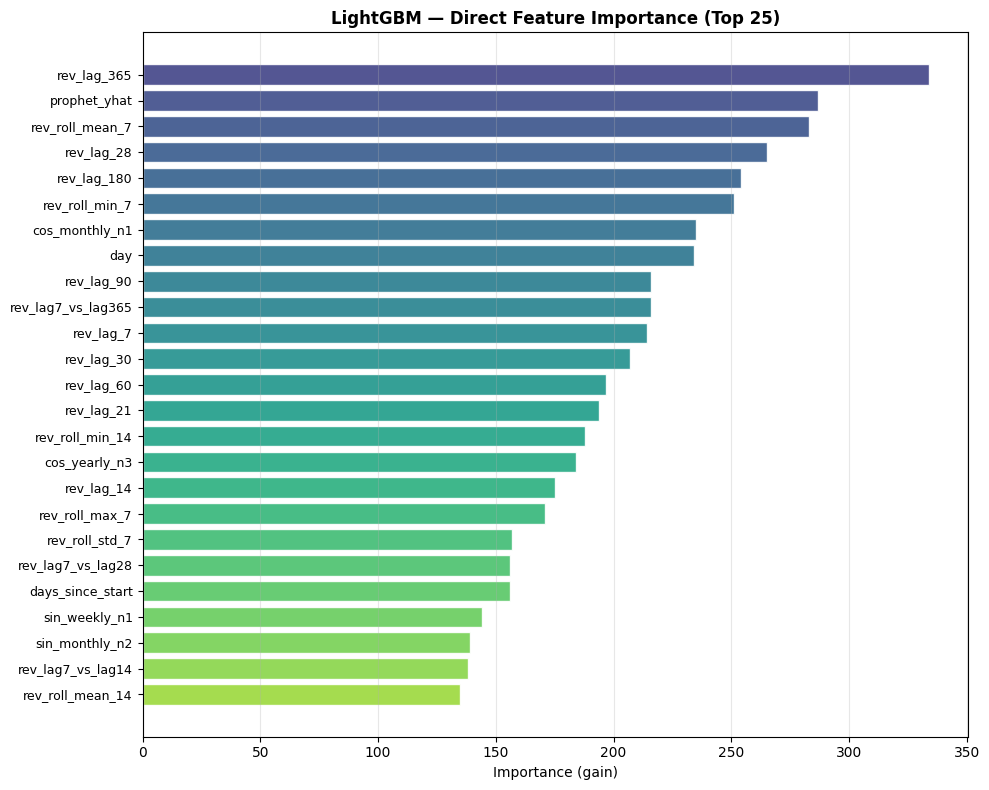

✔ Feature importance plot saved


In [15]:
plt.figure(figsize=(10, 8))
ext_cols_rev = FEATURE_COLS_REV + ['prophet_yhat']
imp = pd.Series(lgbm_final_rev.feature_importances_, index=ext_cols_rev)
top25 = imp.sort_values(ascending=False).head(25)
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(top25)))
plt.barh(range(len(top25)), top25.values[::-1], color=colors[::-1], edgecolor='white', alpha=0.9)
plt.yticks(range(len(top25)), top25.index[::-1], fontsize=9)
plt.title('LightGBM — Direct Feature Importance (Top 25)', fontweight='bold')
plt.xlabel('Importance (gain)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✔ Feature importance plot saved')


## 10. Prediction Visualization (Revenue)

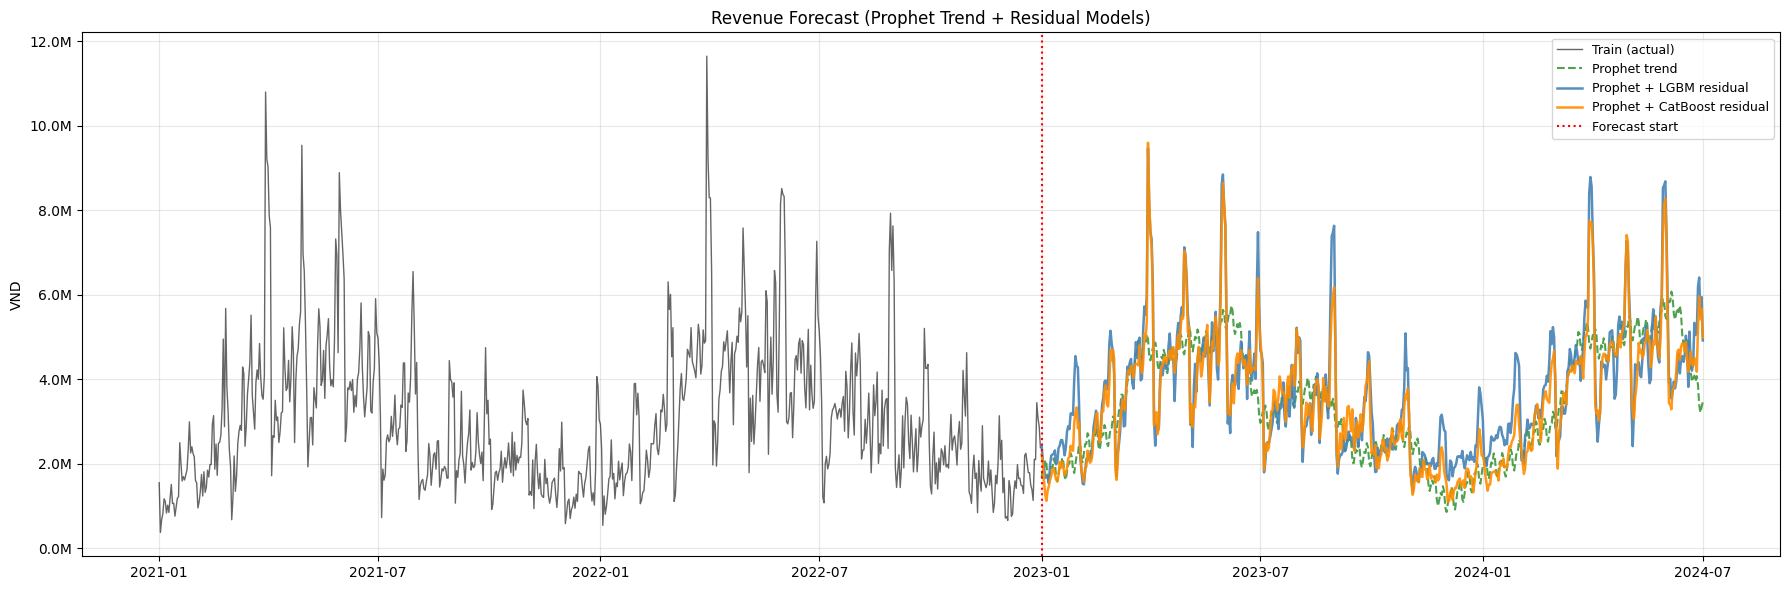

✓ Prediction plot saved


In [16]:
plt.figure(figsize=(18, 6))
train_tail = train[train.date >= '2021-01-01']
plt.plot(train_tail.date, train_tail['Revenue'], color='black', alpha=0.6, lw=1, label='Train (actual)')
plt.plot(test_preds['date'], test_preds['prophet_rev'], color='forestgreen', lw=1.5, linestyle='--', label='Prophet trend', alpha=0.8)
plt.plot(test_preds['date'], test_preds['lgbm_rev'], color='steelblue', lw=1.8, label='Prophet + LGBM residual', alpha=0.9)
plt.plot(test_preds['date'], test_preds['catboost_rev'], color='darkorange', lw=1.8, label='Prophet + CatBoost residual', alpha=0.9)
plt.axvline(x=test_preds['date'].min(), color='red', linestyle=':', lw=1.5, label='Forecast start')
plt.title('Revenue Forecast (Prophet Trend + Residual Models)')
plt.ylabel('VND')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Prediction plot saved')

## Stage 3 Summary

In [17]:
print('=' * 65)
print('STAGE 3 COMPLETE — Prophet Trend + Residual Models (Revenue + COGS)')
print('=' * 65)
print()
print('Models trained:')
print('  ✓ Revenue Prophet    — prophet_rev.pkl')
print('  ✓ Revenue LightGBM   — lgbm_rev.pkl')
print('  ✓ Revenue CatBoost   — catboost_rev.cbm')
print('  ✓ COGS Prophet       — prophet_cogs.pkl')
print('  ✓ COGS LightGBM      — lgbm_cogs.pkl')
print('  ✓ COGS CatBoost      — catboost_cogs.cbm')
print()
print('Backtest window:')
print(f'  ✓ {BACKTEST_START.date()} -> {BACKTEST_END.date()}')
print()
print('Outputs saved:')
for fname in [
    'prophet_rev.pkl',
    'lgbm_rev.pkl',
    'catboost_rev.cbm',
    'prophet_cogs.pkl',
    'lgbm_cogs.pkl',
    'catboost_cogs.cbm',
    'cv_scores.json',
    'oof_predictions.csv',
    'test_predictions.csv',
    'feature_importance.png'
    ]:
    path = os.path.join(OUTPUT_DIR, fname)
    size = os.path.getsize(path)/1024 if os.path.exists(path) else 0
    print(f'  {fname:<30} {size:>8.1f} KB')
print()
print('→ Stage 4: blend for both Revenue and COGS')

STAGE 3 COMPLETE — Prophet Trend + Residual Models (Revenue + COGS)

Models trained:
  ✓ Revenue Prophet    — prophet_rev.pkl
  ✓ Revenue LightGBM   — lgbm_rev.pkl
  ✓ Revenue CatBoost   — catboost_rev.cbm
  ✓ COGS Prophet       — prophet_cogs.pkl
  ✓ COGS LightGBM      — lgbm_cogs.pkl
  ✓ COGS CatBoost      — catboost_cogs.cbm

Backtest window:
  ✓ 2021-01-01 -> 2022-12-31

Outputs saved:
  prophet_rev.pkl                   171.1 KB
  lgbm_rev.pkl                      664.4 KB
  catboost_rev.cbm                  375.0 KB
  prophet_cogs.pkl                  171.1 KB
  lgbm_cogs.pkl                     540.5 KB
  catboost_cogs.cbm                 207.7 KB
  cv_scores.json                      0.8 KB
  oof_predictions.csv               157.5 KB
  test_predictions.csv              106.1 KB
  feature_importance.png             81.8 KB

→ Stage 4: blend for both Revenue and COGS


---
**Next**: Stage 4 sẽ dùng holdout `2021-2022` để blend giữa hai đường dự báo `Prophet+LGBM residual` và `Prophet+CatBoost residual`.